# 🛡️ Brute Force Attack Detection Using Machine Learning

**Assignment Overview:** The primary goal of this project is to develop and evaluate models capable of Brute Force Attack Detection.

### 📊 Dataset Information
* **Source:** Kaggle Dataset
* **Link:** https://www.kaggle.com/datasets/solarmainframe/ids-intrusion-csv?select=02-14-2018.csv
* **Dataset Name:** IDS 2018 Intrusion CSVs (CSE-CIC-IDS2018) – 02-14-2018.csv
* **Total Records:** 1,048,575 network flow records
* **Features:** 80 columns (79 input features + 1 target label)

### 🎯 Machine Learning Approach
* **Learning Type:** Supervised Learning
* **Reason:** The dataset contains input features and known labels.
* **Problem Type:** Classification
* **Reason:** The model predicts whether the traffic is Normal or a Brute force attack.
* **Target Classes:** The target variable is the "Label" column. The model will classify traffic as Benign (Normal traffic) or a Brute Force Attack (FTP / SSH).

### 1. Importing Essential Libraries
Before analyzing the dataset, we must load our required Python packages. We use Pandas and NumPy for data manipulation, Matplotlib and Seaborn for visual exploratory data analysis (EDA), and Scikit-Learn to build, train, and evaluate our machine learning and deep learning models.

In [7]:
# Let's bring in all the tools we need for the project.
import pandas as pd
import numpy as np

# These are our charting tools to make things look pretty
import matplotlib.pyplot as plt
import seaborn as sns

# We'll use this later to save our finished model
import joblib

# Python likes to throw messy warnings, so let's just turn them off
import warnings
warnings.filterwarnings("ignore")

# Tools for prepping our data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# The 4 standard Machine Learning algorithms we need to test
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# The Deep Learning/Neural Network models
from sklearn.neural_network import MLPClassifier

# Our grading rubric (how we check if the models are actually good)
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


### 2. Loading and Exploratory Data Analysis (EDA)
In this Exploratory Data Analysis (EDA) step, we will fulfill our assignment requirements:
1. **Dataset Overview:** Check the shape of the dataset, column names, and data types.
2. **Class Distribution:** Count the number of records in each label to check for class imbalance.
3. **Feature Statistics:** Check the Mean, Standard Deviation, and Min/Max of our features.
4. **Distribution Plots:** Use histograms to show feature distributions.

Loading the dataset... this might take a second for a large file!
Dataset Shape: (1048575, 80)

First 5 rows just to make sure it looks right:
   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0         0         0  14/02/2018 08:31:01      112641719             3   
1         0         0  14/02/2018 08:33:50      112641466             3   
2         0         0  14/02/2018 08:36:39      112638623             3   
3        22         6  14/02/2018 08:40:13        6453966            15   
4        22         6  14/02/2018 08:40:23        8804066            14   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             0                0                0                0   
1             0                0                0                0   
2             0                0                0                0   
3            10             1239             2273              744   
4            11             1143             2209       

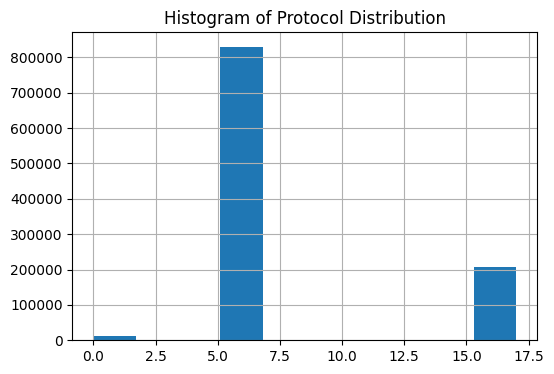

In [8]:
print("Loading the dataset... this might take a second for a large file!")
data = pd.read_csv("02-14-2018.csv")

# Let's see how huge this dataset is
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows just to make sure it looks right:")
print(data.head())
print("\nDataset Info (Checking data types):")
print(data.info())

# How many normal records vs attack records do we have?
print("\nLabel Distribution:")
print(data['Label'].value_counts())

# Getting the math stats: Mean, Standard Deviation, Min, Max
print("\nFeature Statistics (Mean, Std, Min, Max):")
print(data.describe())

# Let's draw a quick histogram of the Protocol column to see its distribution
plt.figure(figsize=(6,4))
data['Protocol'].hist(bins=10)
plt.title("Histogram of Protocol Distribution")
plt.show()

### 3. Cleaning the Data
Real-world data is messy. Here, we perform Missing Values Analysis to identify missing values and handle them by removing them. We also perform Outlier Detection by identifying abnormal values (like infinite numbers) and cleaning them out.

In [9]:
# The timestamp doesn't help us spot an attack, so we drop it
if 'Timestamp' in data.columns:
    data.drop('Timestamp', axis=1, inplace=True)

# Sometimes network math creates "infinity". We change those to NaN (Not a Number)
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Now we just throw away any rows that have missing values (NaN)
data.dropna(inplace=True)

print("\nDataset Shape After Cleaning up the mess:", data.shape)


Dataset Shape After Cleaning up the mess: (1044751, 79)


### 4. Preparing Data for Machine Learning
Computers only understand numbers, so we encode our target labels. After that, we scale the data so all features are on a level playing field. Finally, we create our train test split to train the models and test them later.

In [10]:
# Convert words like 'Benign' into numbers the computer can read
encoder = LabelEncoder()
data['Label'] = encoder.fit_transform(data['Label'])
print("\nEncoded Labels mapping:", encoder.classes_)

# Separate our clues (X) from the answers we are trying to guess (y)
X = data.drop("Label", axis=1)
y = data["Label"]

# Scale the data so large numbers don't drown out the small numbers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split it up: 80% to train the model, 20% to test it like a final exam
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Encoded Labels mapping: ['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']

Training samples: (835800, 78)
Testing samples: (208951, 78)


### 5. Evaluation Metrics & Visualizations
We will use the following strategies to understand patterns and evaluate our models:
* **Accuracy:** Measures overall correct predictions. Formula: $Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$
* **Precision:** Measures how many predicted attacks are actually attacks. Formula: $Precision = \frac{TP}{TP + FP}$
* **Recall (Detection Rate):** Measures how many attacks were correctly detected. Formula: $Recall = \frac{TP}{TP + FN}$
* **F1 Score:** Balance between precision and recall. Formula: $F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}$
* **ROC-AUC Score:** Measures the model’s ability to distinguish classes (Higher AUC → Better model).


We also use a Confusion Matrix heatmap to visualize prediction performance, showing Actual Attacks versus Predicted Attacks.

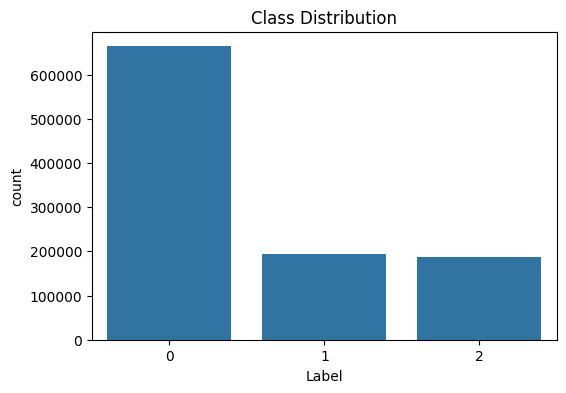

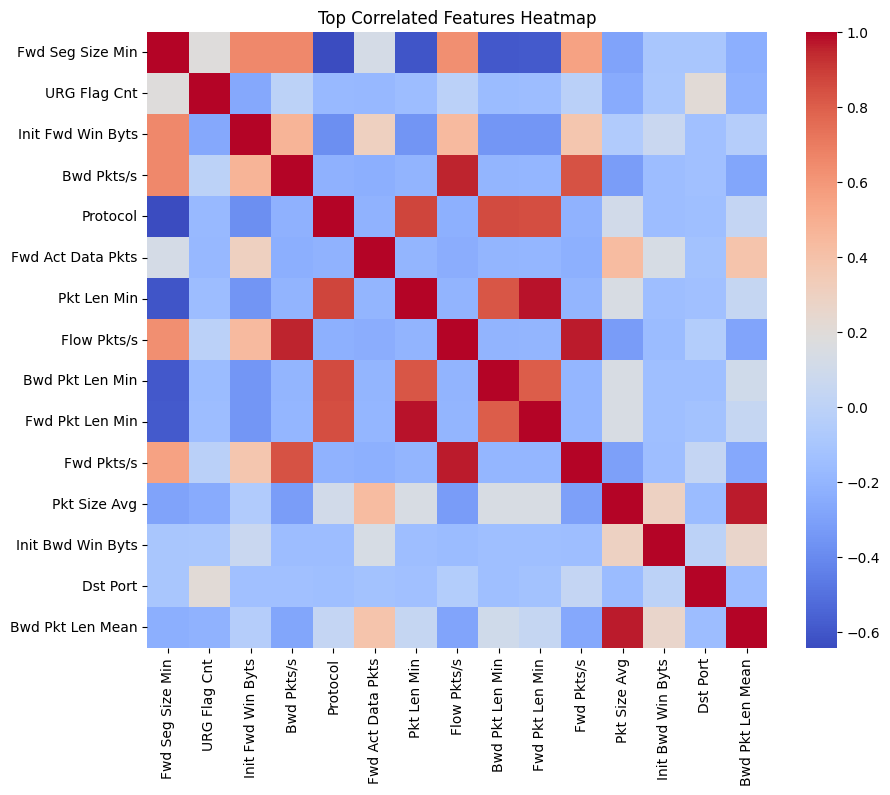

In [13]:
# Let's visualize the balance between benign and attack traffic
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

# Find which features are most closely related to the label
numeric_data = data.select_dtypes(include=[np.number])
correlations = numeric_data.corr()['Label'].abs().sort_values(ascending=False)
top_features = correlations.index[1:16]

# Draw a heatmap of these top relationships
plt.figure(figsize=(10,8))
sns.heatmap(data[top_features].corr(), cmap="coolwarm")
plt.title("Top Correlated Features Heatmap")
plt.show()

# I'm making a reusable grading function so we don't have to copy/paste this 6 times!
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    # Train it
    model.fit(X_train, y_train)

    # Let it take the test
    y_pred = model.predict(X_test)

    # Calculate its grades
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n--- {model_name} Performance ---")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    # ROC Curve Visualization (if the model supports probability predictions)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)

        # Calculate overall ROC-AUC score
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
        print("ROC-AUC Score:", roc_auc)

        # Binarize labels to draw the curve for each class (Benign, FTP, SSH)
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        n_classes = y_test_bin.shape[1]

        plt.figure(figsize=(6,4))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            class_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {class_auc:.2f})')

        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc="lower right")
        plt.show()

    # Show exactly where it got confused using a heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

    return accuracy

### 6. Training the Algorithms
We will now train the required algorithms.

**4 Machine Learning Algorithms:**
1. **Logistic Regression:** Simple baseline classification model that works well for binary classification.
2. **Decision Tree:** Tree-based model that is easy to interpret.
3. **Random Forest:** Ensemble learning method that combines multiple decision trees and handles large datasets well.
4. **Support Vector Machine (SVM):** Effective for high-dimensional data, finding the optimal separating hyperplane.


**2 Basic Deep Learning Algorithms:**
1. **Artificial Neural Network (ANN):** Fully connected neural network that can capture complex patterns in network traffic.
2. **Deep Neural Network (DNN) / Multi-Layer Perceptron (MLP):** Uses multiple hidden layers for better feature learning capability.


===== 1. Logistic Regression =====

Accuracy : 0.999588420251638
Precision: 0.9995892024894766
Recall   : 0.999588420251638
F1 Score : 0.9995885638690931


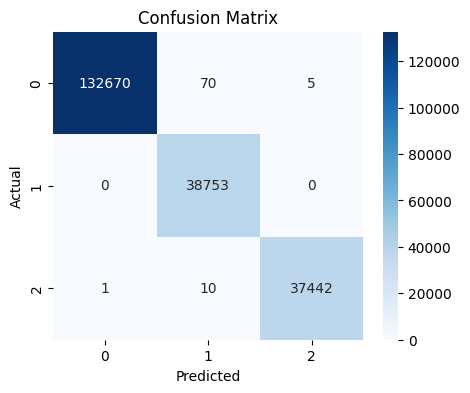


Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     38753
           2       1.00      1.00      1.00     37453

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951


===== 2. Decision Tree =====

Accuracy : 0.9999521418897254
Precision: 0.9999521542360634
Recall   : 0.9999521418897254
F1 Score : 0.9999521417817371


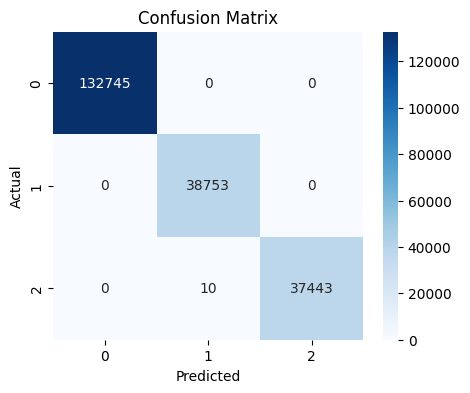


Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     38753
           2       1.00      1.00      1.00     37453

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951


===== 3. Random Forest =====

Accuracy : 0.9999521418897254
Precision: 0.9999521542360634
Recall   : 0.9999521418897254
F1 Score : 0.9999521417817371


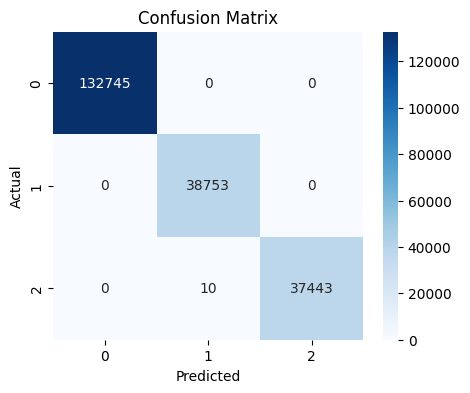


Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     38753
           2       1.00      1.00      1.00     37453

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951



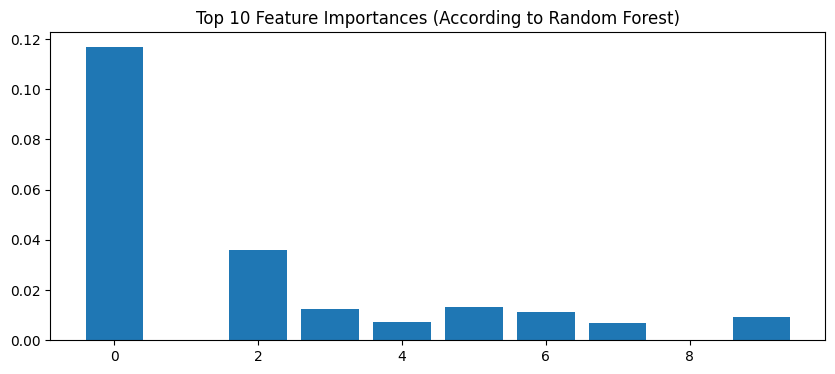


===== 4. Support Vector Machine =====

Accuracy : 0.9999329986456155
Precision: 0.9999330150731597
Recall   : 0.9999329986456155
F1 Score : 0.9999329991846848


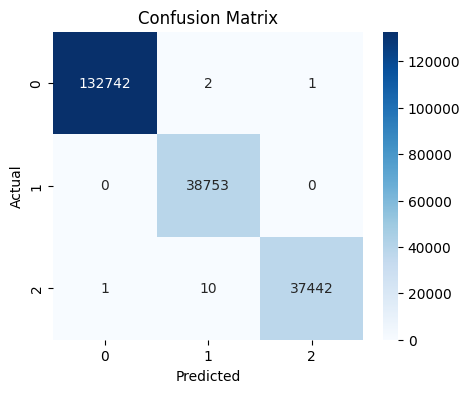


Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     38753
           2       1.00      1.00      1.00     37453

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951


===== 5. Artificial Neural Network (ANN) =====

Accuracy : 0.9999473560786979
Precision: 0.9999473672747236
Recall   : 0.9999473560786979
F1 Score : 0.9999473559936883


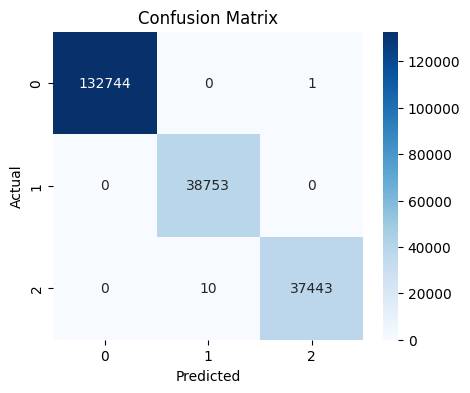


Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     38753
           2       1.00      1.00      1.00     37453

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951


===== 6. Deep Neural Network (DNN) =====

Accuracy : 0.9999521418897254
Precision: 0.9999521542360634
Recall   : 0.9999521418897254
F1 Score : 0.9999521417817371


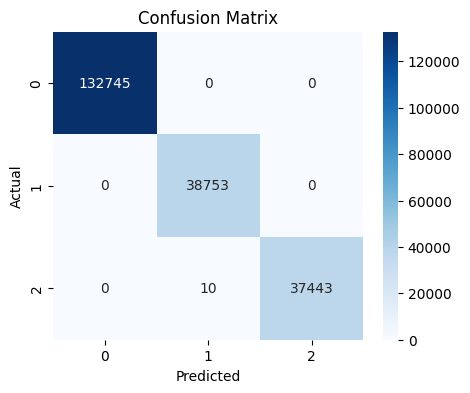


Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     38753
           2       1.00      1.00      1.00     37453

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951



In [12]:
# We'll store everyone's final score here
results = {}

print("\n===== 1. Logistic Regression =====")
lr = LogisticRegression(max_iter=1000)
results["Logistic Regression"] = evaluate_model(lr, X_train, X_test, y_train, y_test)

print("\n===== 2. Decision Tree =====")
dt = DecisionTreeClassifier()
results["Decision Tree"] = evaluate_model(dt, X_train, X_test, y_train, y_test)

print("\n===== 3. Random Forest =====")
rf = RandomForestClassifier(n_estimators=100)
results["Random Forest"] = evaluate_model(rf, X_train, X_test, y_train, y_test)

# We can actually ask the Random Forest which features were the most important!
plt.figure(figsize=(10,4))
plt.bar(range(10), rf.feature_importances_[:10])
plt.title("Top 10 Feature Importances (According to Random Forest)")
plt.show()

print("\n===== 4. Support Vector Machine =====")
# Note: SVM can be a bit slow on huge datasets, so be patient while this one runs.
svm = SVC()
results["SVM"] = evaluate_model(svm, X_train, X_test, y_train, y_test)

print("\n===== 5. Artificial Neural Network (ANN) =====")
ann = MLPClassifier(hidden_layer_sizes=(64,), max_iter=100)
results["ANN"] = evaluate_model(ann, X_train, X_test, y_train, y_test)

print("\n===== 6. Deep Neural Network (DNN) =====")
# This one has multiple layers to dig deeper into the data patterns
dnn = MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=100)
results["DNN"] = evaluate_model(dnn, X_train, X_test, y_train, y_test)

### 7. Compare and Save the Best Model
Once we know which model performed the best on our accuracy metrics, we save it as a `.pkl` file. We also save the scaler so future data is prepped the exact same way.

In [14]:
print("\n--- Final Model Accuracy Leaderboard ---")
for model, score in results.items():
    print(model, ":", score)

# Grab the name of the winner automatically
best_model_name = max(results, key=results.get)
print("\nThe Best Model is:", best_model_name)

# Link the names back to the actual model objects
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "ANN": ann,
    "DNN": dnn
}

best_model = models[best_model_name]

# Save the winning model to a file so we don't have to retrain it tomorrow
joblib.dump(best_model, "bruteforce_attack_detection_model.pkl")
print("\nModel saved successfully to your Colab files!")

# Save the scaler too, this is super important for testing new data later
joblib.dump(scaler, "feature_scaler.pkl")
print("Scaler saved successfully!")


--- Final Model Accuracy Leaderboard ---
Logistic Regression : 0.999588420251638
Decision Tree : 0.9999521418897254
Random Forest : 0.9999521418897254
SVM : 0.9999329986456155
ANN : 0.9999473560786979
DNN : 0.9999521418897254

The Best Model is: Decision Tree

Model saved successfully to your Colab files!
Scaler saved successfully!
